# Imports and setup

In [41]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import miceforest as mf
import os

# Reading the gut dictionary file

In [42]:
# Load gut_NCBI_dict
with open('data/raw/gut_NCBI_dict', 'rb') as file:
    gut_NCBI_dict = pickle.load(file)

# Conversion to a data frame

In [43]:
# Create taxa and metadata dataframes
df1 = pd.DataFrame({ID: gut_NCBI_dict[ID]['Taxa'] for ID in gut_NCBI_dict.keys()}).T
df2 = pd.DataFrame({ID: gut_NCBI_dict[ID]['Attributes'] for ID in gut_NCBI_dict.keys()}).T

print(f"Loaded {len(gut_NCBI_dict)} samples")
print(f"Taxa shape: {df1.shape}, Metadata shape: {df2.shape}")
print()

Loaded 17320 samples
Taxa shape: (17320, 6007), Metadata shape: (17320, 796)



In [44]:
df1.head()

,sk__Archaea,sk__Archaea;k__;p__Candidatus_Aenigmarchaeota,sk__Archaea;k__;p__Candidatus_Altiarchaeota;c__;o__Candidatus_Altiarchaeales,sk__Archaea;k__;p__Candidatus_Diapherotrites,sk__Archaea;k__;p__Candidatus_Micrarchaeota,sk__Archaea;k__;p__Candidatus_Woesearchaeota,sk__Archaea;k__;p__Crenarchaeota,sk__Archaea;k__;p__Euryarchaeota,sk__Archaea;k__;p__Euryarchaeota;c__;o__;f__;g__;s__Euryarchaeota_archaeon_SCGC_AAA286-E23,sk__Archaea;k__;p__Euryarchaeota;c__Candidatus_Poseidoniia,...,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Solanaceae;g__Nicotiana,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Solanaceae;g__Solanum,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales;f__Musaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales;f__Zingiberaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae;g__Juniperus,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae;g__Juniperus;s__Juniperus_monosperma,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Taxaceae;g__Taxus
ERR1073895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1073906,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1073918,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1073929,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1073937,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
df2.head()

,ENA first public,ENA last update,ENA-CHECKLIST,External Id,INSDC center alias,INSDC center name,INSDC first public,INSDC last update,INSDC status,Submitter Id,...,host body product,host tissue sampled,host height,host weight,host_age_normalized_years,host_age_units,host_height_units,host_weight_units,life stage,env matter
ERR1073895,2015-10-15,2017-08-10,ERC000011,SAMEA3608840,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:16Z,2017-08-10T16:56:16Z,public,qiita_sid_10317:10317.000005553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1073906,2015-10-15,2017-08-10,ERC000011,SAMEA3608851,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:16Z,2017-08-10T16:56:16Z,public,qiita_sid_10317:10317.000005750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1073918,2015-10-15,2017-08-10,ERC000011,SAMEA3608863,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:19Z,2017-08-10T16:56:17Z,public,qiita_sid_10317:10317.000005845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1073929,2015-10-15,2017-08-10,ERC000011,SAMEA3608874,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:16Z,2017-08-10T16:56:18Z,public,qiita_sid_10317:10317.000005924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1073937,2015-10-15,2017-08-10,ERC000011,SAMEA3608882,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:23Z,2017-08-10T16:56:18Z,public,qiita_sid_10317:10317.000005966,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filter data for IBD and healthy participants

Create filtered datasets for:
1. IBD patients (subset_ibd = False)
2. Healthy individuals (subset_healthy = True)


In [46]:
df_ibd = df2[df2['subset_ibd'].str.lower() == 'false']
df_healthy = df2[df2['subset_healthy'].str.lower() == 'true']
df_filtered_meta = pd.concat([df_ibd, df_healthy], ignore_index=False)
df_filtered_taxa = df1.loc[df_filtered_meta.index]

print(f"Filtered samples: {len(df_ibd)} IBD, {len(df_healthy)} healthy (total {len(df_filtered_meta)})")
print()

Filtered samples: 1880 IBD, 6311 healthy (total 8191)



In [47]:
df_filtered_taxa.head()

,sk__Archaea,sk__Archaea;k__;p__Candidatus_Aenigmarchaeota,sk__Archaea;k__;p__Candidatus_Altiarchaeota;c__;o__Candidatus_Altiarchaeales,sk__Archaea;k__;p__Candidatus_Diapherotrites,sk__Archaea;k__;p__Candidatus_Micrarchaeota,sk__Archaea;k__;p__Candidatus_Woesearchaeota,sk__Archaea;k__;p__Crenarchaeota,sk__Archaea;k__;p__Euryarchaeota,sk__Archaea;k__;p__Euryarchaeota;c__;o__;f__;g__;s__Euryarchaeota_archaeon_SCGC_AAA286-E23,sk__Archaea;k__;p__Euryarchaeota;c__Candidatus_Poseidoniia,...,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Solanaceae;g__Nicotiana,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Solanales;f__Solanaceae;g__Solanum,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales;f__Musaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Magnoliopsida;o__Zingiberales;f__Zingiberaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae;g__Juniperus,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Cupressaceae;g__Juniperus;s__Juniperus_monosperma,sk__Eukaryota;k__Viridiplantae;p__Streptophyta;c__Pinopsida;o__Cupressales;f__Taxaceae;g__Taxus
ERR1073977,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1073993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1080025,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1080049,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ERR1846202,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
df_filtered_meta.head()

,ENA first public,ENA last update,ENA-CHECKLIST,External Id,INSDC center alias,INSDC center name,INSDC first public,INSDC last update,INSDC status,Submitter Id,...,host body product,host tissue sampled,host height,host weight,host_age_normalized_years,host_age_units,host_height_units,host_weight_units,life stage,env matter
ERR1073977,2015-10-15,2017-08-10,ERC000011,SAMEA3608922,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:23Z,2017-08-10T16:56:20Z,public,qiita_sid_10317:10317.000006659,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1073993,2015-10-15,2017-08-10,ERC000011,SAMEA3608938,UCSDMI,University of California San Diego Microbiome ...,2015-10-15T17:01:22Z,2017-08-10T16:56:21Z,public,qiita_sid_10317:10317.000006711,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1080025,2015-10-20,2017-08-09,ERC000011,SAMEA3628116,UCSDMI,University of California San Diego Microbiome ...,2015-10-20T17:21:58Z,2017-08-09T14:57:29Z,public,qiita_sid_10317:10317.000016012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1080049,2015-10-20,2017-08-09,ERC000011,SAMEA3628140,UCSDMI,University of California San Diego Microbiome ...,2015-10-20T17:21:59Z,2017-08-09T14:57:30Z,public,qiita_sid_10317:10317.000017608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ERR1846202,NaN,NaN,NaN,NaN,NaN,UCSDMI,2017-02-20T17:01:32Z,2017-08-06T13:17:09Z,public,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Checking the most reported attributes

In [49]:
# Find which attributes have actual data (not "Not provided") in most samples
print("=== Attributes with Most Data Coverage ===")
print("Finding which attributes have actual (non-'Not provided') values...\n")

# Count actual data for each attribute/column across all samples
attribute_coverage = []

for attr_name in df_filtered_meta.columns:
    # Get the column
    col = df_filtered_meta[attr_name]
    
    # Total count (all non-null values - these are actual rows with this attribute)
    total_count = col.notna().sum()
    
    # Count values that are NOT "Not provided" (actual data)
    # Handle NaN values by treating them as "Not provided"
    data_count = (col.notna() & (col.astype(str).str.lower() != 'not provided')).sum()
    
    # Calculate coverage percentage
    if total_count > 0:
        coverage_percentage = (data_count / total_count) * 100
    else:
        coverage_percentage = 0
    
    attribute_coverage.append({
        'attribute': attr_name,
        'data_count': data_count,
        'total_count': total_count,
        'coverage_percentage': coverage_percentage
    })

# Sort by data count (descending)
attribute_coverage.sort(key=lambda x: x['data_count'], reverse=True)

print(f"{'Rank':<4} {'Attribute':<50} {'With Data':<12} {'Total':<8} {'Coverage %':<10}")
print("-" * 90)

for i, stat in enumerate(attribute_coverage):
    print(f"{i+1:<4} {stat['attribute']:<50} {stat['data_count']:<12} {stat['total_count']:<8} {stat['coverage_percentage']:<10.1f}")

# Summary statistics
print(f"\n=== Coverage Summary ===")
print(f"Total attributes: {len(attribute_coverage)}")
print(f"Attributes with >90% coverage: {len([a for a in attribute_coverage if a['coverage_percentage'] > 90])}")
print(f"Attributes with >50% coverage: {len([a for a in attribute_coverage if a['coverage_percentage'] > 50])}")
print(f"Attributes with >10% coverage: {len([a for a in attribute_coverage if a['coverage_percentage'] > 10])}")


=== Attributes with Most Data Coverage ===
Finding which attributes have actual (non-'Not provided') values...

Rank Attribute                                          With Data    Total    Coverage %
------------------------------------------------------------------------------------------
1    INSDC center name                                  8191         8191     100.0     
2    INSDC first public                                 8191         8191     100.0     
3    INSDC last update                                  8191         8191     100.0     
4    INSDC status                                       8191         8191     100.0     
5    body habitat                                       8191         8191     100.0     
6    body product                                       8191         8191     100.0     
7    tissue                                             8191         8191     100.0     
8    environmental medium                               8191         8191     100.0  

# Selecting attributes and filtering for unique values

In [50]:
# Define attributes to analyze 
# These attributes were chosen based on the coverage analysis and relevance to disease classification and will be used as input to the CNN model
selected_attributes = [
    'age_corrected',
    'sex',
    'race',
    'geographic location',
    'bmi_cat',
    'alcohol_frequency',
    'sleep_duration',
    'exercise_frequency',
    'smoking_frequency',
    'antibiotic_history'
]

# Filter to create df_selected_meta with only selected columns (index preserved automatically)
df_selected_meta = df_filtered_meta[selected_attributes].copy()

print(f"✓ Created df_selected_meta")
print(f"   Shape: {df_selected_meta.shape}")
print(f"   Columns: {list(df_selected_meta.columns)}\n")

# Check unique values for each attribute
print("\n=== Unique Values for Selected Attributes ===\n")

for attr in selected_attributes:
    if attr in df_selected_meta.columns:
        unique_vals = df_selected_meta[attr].dropna().unique()
        value_counts = df_selected_meta[attr].value_counts(dropna=False)
        print(f"{attr.upper()}")
        print(f"   Unique values: {len(unique_vals)}")
        print(f"   Values:")
        for val, count in value_counts.items():
            print(f"      • {val}: {count} samples")
        print()
    else:
        print(f"{attr} - NOT FOUND in dataframe")
        print()

✓ Created df_selected_meta
   Shape: (8191, 10)
   Columns: ['age_corrected', 'sex', 'race', 'geographic location', 'bmi_cat', 'alcohol_frequency', 'sleep_duration', 'exercise_frequency', 'smoking_frequency', 'antibiotic_history']


=== Unique Values for Selected Attributes ===

AGE_CORRECTED
   Unique values: 140
   Values:
      • Not provided: 343 samples
      • 68.0: 245 samples
      • 69.0: 210 samples
      • 33.0: 200 samples
      • 37.0: 188 samples
      • 48.0: 185 samples
      • 51.0: 182 samples
      • 34.0: 181 samples
      • 49.0: 178 samples
      • 36.0: 173 samples
      • 45.0: 170 samples
      • 35.0: 169 samples
      • 38.0: 168 samples
      • 53.0: 165 samples
      • 42.0: 164 samples
      • 44.0: 160 samples
      • 52.0: 160 samples
      • 47.0: 159 samples
      • 55.0: 157 samples
      • 50.0: 155 samples
      • 43.0: 154 samples
      • 46.0: 152 samples
      • 41.0: 151 samples
      • 59.0: 150 samples
      • 54.0: 150 samples
      • 58.0: 1

In [51]:
df_selected_meta.head()

,age_corrected,sex,race,geographic location,bmi_cat,alcohol_frequency,sleep_duration,exercise_frequency,smoking_frequency,antibiotic_history
ERR1073977,57.0,female,Caucasian,USA,Normal,Never,5-6 hours,Occasionally (1-2 timesweek),Never,Month
ERR1073993,69.0,female,Caucasian,USA,Not provided,Daily,8 or more hours,Regularly (3-5 timesweek),Never,Week
ERR1080025,34.0,female,Caucasian,United Kingdom,Normal,Occasionally (1-2 timesweek),6-7 hours,Rarely (a few timesmonth),Rarely (a few timesmonth),Year
ERR1080049,Not provided,Not provided,Not provided,USA,Not provided,Not provided,Not provided,Not provided,Not provided,Not provided
ERR1846202,17.0,male,Caucasian,USA:SC,Normal,Never,7-8 hours,Regularly (3-5 timesweek),Never,I have not taken antibiotics in the past year.


# Unify missing values

In [52]:
# Define missing value variants to replace with NaN based on the unique values observed in the previous step
missing_value_variants = [
    'Not provided',
    'not provided',
    'Unspecified',
    'unspecified',
    'nan'
]

# Create a copy to preserve original
df_selected_meta_nan = df_selected_meta.copy()

# Replace all missing value variants with NaN
for variant in missing_value_variants:
    df_selected_meta_nan = df_selected_meta_nan.replace(variant, np.nan)

print("✓ Unified missing values (all variants replaced with NaN)")
print(f"Original shape: {df_selected_meta.shape}, Cleaned shape: {df_selected_meta_nan.shape}")
print()


✓ Unified missing values (all variants replaced with NaN)
Original shape: (8191, 10), Cleaned shape: (8191, 10)



# Check for unique values for each selected attribute

In [53]:
# Check unique values for each attribute
print("\n=== Unique Values for Selected Attributes ===\n")

for attr in selected_attributes:
    if attr in df_selected_meta_nan.columns:
        unique_vals = df_selected_meta_nan[attr].dropna().unique()
        value_counts = df_selected_meta_nan[attr].value_counts(dropna=False)
        print(f"{attr.upper()}")
        print(f"   Unique values: {len(unique_vals)}")
        print(f"   Values:")
        for val, count in value_counts.items():
            print(f"      • {val}: {count} samples")
        print()
    else:
        print(f"{attr} - NOT FOUND in dataframe")
        print()


=== Unique Values for Selected Attributes ===

AGE_CORRECTED
   Unique values: 138
   Values:
      • nan: 481 samples
      • 68.0: 245 samples
      • 69.0: 210 samples
      • 33.0: 200 samples
      • 37.0: 188 samples
      • 48.0: 185 samples
      • 51.0: 182 samples
      • 34.0: 181 samples
      • 49.0: 178 samples
      • 36.0: 173 samples
      • 45.0: 170 samples
      • 35.0: 169 samples
      • 38.0: 168 samples
      • 53.0: 165 samples
      • 42.0: 164 samples
      • 44.0: 160 samples
      • 52.0: 160 samples
      • 47.0: 159 samples
      • 55.0: 157 samples
      • 50.0: 155 samples
      • 43.0: 154 samples
      • 46.0: 152 samples
      • 41.0: 151 samples
      • 59.0: 150 samples
      • 54.0: 150 samples
      • 58.0: 149 samples
      • 60.0: 148 samples
      • 31.0: 147 samples
      • 40.0: 144 samples
      • 63.0: 144 samples
      • 61.0: 140 samples
      • 57.0: 140 samples
      • 65.0: 140 samples
      • 39.0: 140 samples
      • 30.0: 139 samp

# Distribution of NaN values across the selected attributes

In [54]:
# Calculate NaN statistics without modifying the dataframe
nan_counts = df_selected_meta_nan[selected_attributes].isna().sum(axis=1)
nan_percentages = (nan_counts / len(selected_attributes)) * 100

# Summary statistics
print("=== NaN Analysis Across Key Attributes ===\n")
print(f"Total samples: {len(df_selected_meta_nan)}")
print(f"Total key attributes analyzed: {len(selected_attributes)}\n")

nan_stats = nan_counts.value_counts().sort_index()
print("NaN Count Distribution:")
for nan_count, num_samples in nan_stats.items():
    percentage = (num_samples / len(df_selected_meta_nan)) * 100
    print(f"   {int(nan_count):2d} NaN values: {num_samples:4d} samples ({percentage:5.1f}%)")

print(f"\n=== Summary ===")
print(f"Samples with NO missing values: {(nan_counts == 0).sum()}")
print(f"Samples with ALL values missing: {(nan_counts == len(selected_attributes)).sum()}")
print(f"Samples with ≥ 50% values missing: {(nan_percentages >= 50).sum()}")
print(f"Samples with ≥ 80% values missing: {(nan_percentages >= 80).sum()}")

print()

=== NaN Analysis Across Key Attributes ===

Total samples: 8191
Total key attributes analyzed: 10

NaN Count Distribution:
    0 NaN values: 7212 samples ( 88.0%)
    1 NaN values:  455 samples (  5.6%)
    2 NaN values:   80 samples (  1.0%)
    3 NaN values:   47 samples (  0.6%)
    4 NaN values:   30 samples (  0.4%)
    5 NaN values:   12 samples (  0.1%)
    6 NaN values:   34 samples (  0.4%)
    7 NaN values:   37 samples (  0.5%)
    8 NaN values:   98 samples (  1.2%)
    9 NaN values:  182 samples (  2.2%)
   10 NaN values:    4 samples (  0.0%)

=== Summary ===
Samples with NO missing values: 7212
Samples with ALL values missing: 4
Samples with ≥ 50% values missing: 367
Samples with ≥ 80% values missing: 284



# Dropping the samples with all 10 attributes missing

In [55]:
# Drop samples with all attributes missing (using temporary Series, not dataframe column)
samples_to_drop = nan_counts[nan_counts == len(selected_attributes)].index

print(f"Dropping {len(samples_to_drop)} samples with all {len(selected_attributes)} attributes missing")

# Filter out the samples with all missing values
df_selected_meta_nan = df_selected_meta_nan.loc[nan_counts < len(selected_attributes)]

print(f"Remaining samples: {len(df_selected_meta_nan)}")
print(f"Removed {len(samples_to_drop)} samples")
print()

Dropping 4 samples with all 10 attributes missing
Remaining samples: 8187
Removed 4 samples



# Align taxa and metadata data frames

In [56]:
df_selected_meta_nan.shape

(8187, 10)

In [57]:
# Filter taxa to match encoded metadata indices
df_filtered_taxa = df_filtered_taxa.loc[df_selected_meta_nan.index]

In [58]:
df_filtered_taxa.shape

(8187, 6007)

# NaN values per attribute

In [59]:
# Analyze NaN count per attribute column (for deciding what to drop/keep)
print("=== Attribute Completeness (After Unifying Missing Values) ===\n")
print(f"{'Attribute':<50} {'Non-NaN':<12} {'NaN':<12} {'Completeness %':<15}")
print("-" * 90)

attribute_completeness = []

for attr in selected_attributes:
    if attr in df_selected_meta_nan.columns:
        non_nan_count = df_selected_meta_nan[attr].notna().sum()
        nan_count = df_selected_meta_nan[attr].isna().sum()
        completeness = (non_nan_count / len(df_selected_meta_nan)) * 100
        
        attribute_completeness.append({
            'attribute': attr,
            'non_nan_count': non_nan_count,
            'nan_count': nan_count,
            'completeness': completeness
        })
        
        print(f"{attr:<50} {non_nan_count:<12} {nan_count:<12} {completeness:<15.1f}")

# Sort by completeness
attribute_completeness.sort(key=lambda x: x['completeness'], reverse=True)

=== Attribute Completeness (After Unifying Missing Values) ===

Attribute                                          Non-NaN      NaN          Completeness % 
------------------------------------------------------------------------------------------
age_corrected                                      7710         477          94.2           
sex                                                7792         395          95.2           
race                                               7785         402          95.1           
geographic location                                8019         168          97.9           
bmi_cat                                            7881         306          96.3           
alcohol_frequency                                  7778         409          95.0           
sleep_duration                                     7784         403          95.1           
exercise_frequency                                 7754         433          94.7           
smoking_

# NaN values for IBD vs healthy samples

In [60]:
# Analyze missing values by disease status
# Calculate NaN count for each sample in the key attributes

# Identify samples with at least one missing value
samples_with_missing = nan_counts[nan_counts > 0].index

# Split by disease status
ibd_with_missing = samples_with_missing[samples_with_missing.isin(df_ibd.index)]
healthy_with_missing = samples_with_missing[samples_with_missing.isin(df_healthy.index)]

# Calculate counts and percentages
ibd_missing_count = len(ibd_with_missing)
healthy_missing_count = len(healthy_with_missing)
total_missing = len(samples_with_missing)

ibd_missing_pct = (ibd_missing_count / total_missing * 100) if total_missing > 0 else 0
healthy_missing_pct = (healthy_missing_count / total_missing * 100) if total_missing > 0 else 0

# Also get totals for context
total_ibd = len(df_ibd)
total_healthy = len(df_healthy)

print("=== Samples with Missing Values - Disease Status Breakdown ===\n")
print(f"Total samples with ANY missing values: {total_missing}\n")
print(f"{'Disease':<15} {'Count':<12} {'% of Missing':<15} {'% of Disease':<15}")
print("-" * 60)

ibd_disease_pct = (ibd_missing_count / total_ibd * 100) if total_ibd > 0 else 0
healthy_disease_pct = (healthy_missing_count / total_healthy * 100) if total_healthy > 0 else 0

print(f"{'IBD':<15} {ibd_missing_count:<12} {ibd_missing_pct:<15.1f} {ibd_disease_pct:<15.1f}")
print(f"{'Healthy':<15} {healthy_missing_count:<12} {healthy_missing_pct:<15.1f} {healthy_disease_pct:<15.1f}")
print(f"{'TOTAL':<15} {total_missing:<12}")

print(f"\n=== Context: Total Samples ===")
print(f"Total IBD samples:     {total_ibd}")
print(f"Total Healthy samples: {total_healthy}")
print()


=== Samples with Missing Values - Disease Status Breakdown ===

Total samples with ANY missing values: 979

Disease         Count        % of Missing    % of Disease   
------------------------------------------------------------
IBD             665          67.9            35.4           
Healthy         314          32.1            5.0            
TOTAL           979         

=== Context: Total Samples ===
Total IBD samples:     1880
Total Healthy samples: 6311



# NaN values across attributes for IBD samples

In [61]:
# Analyze attribute-level missingness for IBD samples with any missing values
# Filter to IBD samples only
ibd_selected_meta_nan = df_selected_meta_nan.loc[df_selected_meta_nan.index.isin(df_ibd.index)]

# Filter to those with at least one missing value
ibd_with_any_missing = ibd_selected_meta_nan[ibd_selected_meta_nan.isna().any(axis=1)]

print("=== Attribute Missingness in IBD Samples (with missing values) ===\n")
print(f"Total IBD samples with any missing values: {len(ibd_with_any_missing)}")
print(f"Total IBD samples: {len(df_ibd)}\n")

# Count missing values per attribute
missing_per_attribute = ibd_with_any_missing.isna().sum()

# Calculate percentages relative to ALL IBD samples (not just those with missing values)
missingness_pct = (missing_per_attribute / len(df_ibd)) * 100

# Create a summary table sorted by missingness
missingness_summary = pd.DataFrame({
    'Attribute': missing_per_attribute.index,
    'Missing Count': missing_per_attribute.values,
    'Missing % of All IBD': missingness_pct.values
}).sort_values('Missing Count', ascending=False)

print(f"{'Attribute':<40} {'Missing Count':<15} {'Missing % of All IBD':<20}")
print("-" * 75)
for idx, row in missingness_summary.iterrows():
    print(f"{row['Attribute']:<40} {int(row['Missing Count']):<15} {row['Missing % of All IBD']:<20.1f}")

print(f"\n=== Highest Missingness ===")
highest_missing_attr = missingness_summary.iloc[0]
print(f"Attribute: {highest_missing_attr['Attribute']}")
print(f"Missing in {int(highest_missing_attr['Missing Count'])} samples ({highest_missing_attr['Missing % of All IBD']:.1f}% of all {len(df_ibd)} IBD samples)")
print()


=== Attribute Missingness in IBD Samples (with missing values) ===

Total IBD samples with any missing values: 661
Total IBD samples: 1880

Attribute                                Missing Count   Missing % of All IBD
---------------------------------------------------------------------------
age_corrected                            453             24.1                
antibiotic_history                       418             22.2                
exercise_frequency                       412             21.9                
smoking_frequency                        388             20.6                
alcohol_frequency                        384             20.4                
sleep_duration                           381             20.3                
race                                     369             19.6                
sex                                      313             16.6                
bmi_cat                                  306             16.3                
geog

# Train/test split
We use the split to prevent data leakage. If normalization or other operations are done on the full dataset before splitting, the test set statistics (min, max, mean) influence the normalization parameters. This means the model has indirectly "seen" the test set during preprocessing, which makes your evaluation metrics optimistically biased and the model appears to generalize better than it actually does.

In [62]:
# Create labels: 0=Healthy, 1=IBD
y = np.zeros(len(df_filtered_taxa), dtype=int)
y[df_filtered_taxa.index.isin(df_ibd.index)] = 1

# 80/20 train/test split (stratified)
indices = np.arange(len(df_filtered_taxa))
train_idx, test_idx, _, _ = train_test_split(
    indices, y, test_size=0.2, random_state=42, stratify=y
)

X_train_raw = df_filtered_taxa.iloc[train_idx].values.astype(float)
X_test_raw = df_filtered_taxa.iloc[test_idx].values.astype(float)
y_train = y[train_idx]
y_test = y[test_idx]

n_samples_train = X_train_raw.shape[0]
n_samples_test = X_test_raw.shape[0]
n_features = X_train_raw.shape[1]

# Split metadata into train and test using the same indices as the taxa
df_meta_train = df_selected_meta_nan.iloc[train_idx].copy()
df_meta_test = df_selected_meta_nan.iloc[test_idx].copy()

print(f"Train: {n_samples_train} ({(y_train==1).sum()} IBD), Test: {n_samples_test} ({(y_test==1).sum()} IBD)")

Train: 6549 (1501 IBD), Test: 1638 (375 IBD)


# Imputing NaN values

In [63]:
# DIAGNOSTIC: Quick check of what columns we have and their contents
print("=== QUICK DIAGNOSTIC ===\n")

# Check if these columns exist
print("Do these columns exist in df_meta_train?")
for col in selected_attributes:
    exists = col in df_meta_train.columns
    print(f"  {col}: {exists}")

print("\n\nTotal NaN count per column in training set:")
nan_series = df_meta_train[selected_attributes].isna().sum()
print(nan_series)

print("\n\nFor each ordinal column, show what ACTUAL values exist:")
for col in ['bmi_cat', 'alcohol_frequency', 'sleep_duration', 'exercise_frequency', 'smoking_frequency', 'antibiotic_history']:
    all_vals = df_meta_train[col].dropna()
    if len(all_vals) > 0:
        unique = all_vals.unique()
        print(f"\n{col}:")
        print(f"  Total non-null: {len(all_vals)}")
        print(f"  Unique values: {sorted(unique)[:10]}")  # Show first 10
    else:
        print(f"\n{col}:")
        print(f"  NO NON-NULL VALUES")


=== QUICK DIAGNOSTIC ===

Do these columns exist in df_meta_train?
  age_corrected: True
  sex: True
  race: True
  geographic location: True
  bmi_cat: True
  alcohol_frequency: True
  sleep_duration: True
  exercise_frequency: True
  smoking_frequency: True
  antibiotic_history: True


Total NaN count per column in training set:
age_corrected          388
sex                    307
race                   330
geographic location    138
bmi_cat                249
alcohol_frequency      329
sleep_duration         323
exercise_frequency     342
smoking_frequency      330
antibiotic_history     333
dtype: int64


For each ordinal column, show what ACTUAL values exist:

bmi_cat:
  Total non-null: 6300
  Unique values: ['Normal', 'Obese', 'Overweight', 'Underweight']

alcohol_frequency:
  Total non-null: 6220
  Unique values: ['Daily', 'Never', 'Occasionally (1-2 timesweek)', 'Rarely (a few timesmonth)', 'Regularly (3-5 timesweek)']

sleep_duration:
  Total non-null: 6226
  Unique values: [

In [64]:
# ═══════════════════════════════════════════════════════════════════════════════
# MICE IMPUTATION OF METADATA  (fit on training set only, applied to test set)
# ═══════════════════════════════════════════════════════════════════════════════

print("=== PREPROCESSING WITH MICE (Multivariate Imputation by Chained Equations) ===\n")

# ── Column subgroups (selected_attributes is defined in a previous cell) ──────
nominal_cols = ['sex', 'race', 'geographic location']
ordinal_cols = ['bmi_cat', 'alcohol_frequency', 'sleep_duration',
                'exercise_frequency', 'smoking_frequency', 'antibiotic_history']
numeric_cols = ['age_corrected'] + ordinal_cols

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: PRE-PROCESSING (Leave NaN for MICE to handle)
# ─────────────────────────────────────────────────────────────────────────────

# 1a. AGE — convert to numeric (unify mixed string representations)
print("STEP 1a: Age (age_corrected)")
df_meta_train['age_corrected'] = pd.to_numeric(df_meta_train['age_corrected'], errors='coerce')
df_meta_test['age_corrected']  = pd.to_numeric(df_meta_test['age_corrected'],  errors='coerce')
print(f"  Converted to numeric. Train NaN: {df_meta_train['age_corrected'].isna().sum()}, "
      f"Test NaN: {df_meta_test['age_corrected'].isna().sum()}\n")

# 1b. GEOGRAPHIC LOCATION — collapse to country, rare → 'Other', preserve NaN
print("STEP 1b: Geographic Location")
TOP_COUNTRIES = {'USA', 'United Kingdom', 'Australia', 'Canada', 'Germany'}

def extract_and_group_country(loc):
    if pd.isna(loc):
        return np.nan
    country = str(loc).split(':')[0].strip()
    return country if country in TOP_COUNTRIES else 'Other'

for df in (df_meta_train, df_meta_test):
    df['geographic location'] = df['geographic location'].apply(extract_and_group_country)
print(f"  Collapsed to country. Train NaN: {df_meta_train['geographic location'].isna().sum()}, "
      f"Test NaN: {df_meta_test['geographic location'].isna().sum()}\n")

# 1c. SEX — merge 'other' into NaN (insufficient sample size, n=3)
print("STEP 1c: Sex")
for df in (df_meta_train, df_meta_test):
    df['sex'] = df['sex'].replace({'other': np.nan})
print(f"  Mapped 'other' → NaN. Train NaN: {df_meta_train['sex'].isna().sum()}, "
      f"Test NaN: {df_meta_test['sex'].isna().sum()}\n")

# 1d. RACE — leave as is (NaN stays NaN, 'Other' kept as valid category)
print("STEP 1d: Race")
print(f"  Left as is. Train NaN: {df_meta_train['race'].isna().sum()}, "
      f"Test NaN: {df_meta_test['race'].isna().sum()}\n")

# 1e. ORDINAL COLUMNS — apply integer maps (NaN preserved)
print("STEP 1e: Ordinal Columns - Apply ordinal maps")

BMI_MAP = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
FREQ_MAP = {
    'Never': 0, 'Rarely (a few timesmonth)': 1,
    'Occasionally (1-2 timesweek)': 2, 'Regularly (3-5 timesweek)': 3,
    'Daily': 4,
}
SLEEP_MAP = {
    'Less than 5 hours': 0, '5-6 hours': 1, '6-7 hours': 2,
    '7-8 hours': 3, '8 or more hours': 4,
}
ANTIBIOTIC_MAP = {
    'I have not taken antibiotics in the past year.': 0,
    'Year': 1, '6 months': 2, 'Month': 3, 'Week': 4,
}
ORDINAL_MAPS = {
    'bmi_cat':            BMI_MAP,
    'alcohol_frequency':  FREQ_MAP,
    'sleep_duration':     SLEEP_MAP,
    'exercise_frequency': FREQ_MAP,
    'smoking_frequency':  FREQ_MAP,
    'antibiotic_history': ANTIBIOTIC_MAP,
}

for df in (df_meta_train, df_meta_test):
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)

print("  Applied ordinal maps. Train NaN counts AFTER mapping:")
print(df_meta_train[ordinal_cols].isna().sum().to_string())

# Sanity check: any column that's now all-NaN means the map keys didn't match the data
all_nan_train = df_meta_train[ordinal_cols].columns[df_meta_train[ordinal_cols].isna().all()].tolist()
all_nan_test  = df_meta_test[ordinal_cols].columns[df_meta_test[ordinal_cols].isna().all()].tolist()
if all_nan_train or all_nan_test:
    raise ValueError(
        f"Ordinal columns are all-NaN after mapping — map keys do not match data values. "
        f"Train: {all_nan_train}, Test: {all_nan_test}"
    )
print()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Set dtypes for miceforest
# ─────────────────────────────────────────────────────────────────────────────
print("STEP 2: Set dtypes for MICE")

# Nominal → category (miceforest detects category dtype automatically)
for col in nominal_cols:
    df_meta_train[col] = df_meta_train[col].astype('category')

# Force test categoricals to use the SAME categories as training (essential)
for col in nominal_cols:
    df_meta_test[col] = pd.Categorical(
        df_meta_test[col],
        categories=df_meta_train[col].cat.categories,
    )

# Numeric → float (preserves NaN)
for col in numeric_cols:
    df_meta_train[col] = df_meta_train[col].astype(float)
    df_meta_test[col]  = df_meta_test[col].astype(float)

print(f"  Categorical: {nominal_cols}")
print(f"  Float:       {numeric_cols}\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Fit MICE on training set only
# ─────────────────────────────────────────────────────────────────────────────
print("STEP 3: Fit MICE imputation kernel on training set")
print(f"  Training data shape: {df_meta_train[selected_attributes].shape}")

# miceforest expects a clean RangeIndex; preserve originals for re-attachment after
train_indices = df_meta_train.index.copy()
test_indices  = df_meta_test.index.copy()

train_data_reset = df_meta_train[selected_attributes].reset_index(drop=True)
test_data_reset  = df_meta_test[selected_attributes].reset_index(drop=True)

kernel = mf.ImputationKernel(
    data=train_data_reset,
    num_datasets=1,
    random_state=42,
    save_all_iterations_data=True,
    mean_match_candidates=0,   # disables KDTree-based mean matching
)
kernel.mice(iterations=5, verbose=True)

df_meta_train_imputed = kernel.complete_data(dataset=0).copy()
df_meta_train_imputed.index = train_indices  # restore original index
print("  Training imputation complete.\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Apply trained MICE imputer to test set
# ─────────────────────────────────────────────────────────────────────────────
print("STEP 4: Applying trained MICE imputer to test set")
new_data_kernel = kernel.impute_new_data(new_data=test_data_reset)
df_meta_test_imputed = new_data_kernel.complete_data(dataset=0).copy()
df_meta_test_imputed.index = test_indices  # restore original index
print("  Test imputation complete.\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Post-process (round & clip to valid ranges)
# ─────────────────────────────────────────────────────────────────────────────
print("STEP 5: Post-processing imputed values")

# Age: round to integer, clip to plausible range
for df in (df_meta_train_imputed, df_meta_test_imputed):
    df['age_corrected'] = df['age_corrected'].round().clip(0, 100).astype(int)

# Ordinals: round and clip to their valid integer range
ordinal_ranges = {
    'bmi_cat':            (0, 3),
    'alcohol_frequency':  (0, 4),
    'sleep_duration':     (0, 4),
    'exercise_frequency': (0, 4),
    'smoking_frequency':  (0, 4),
    'antibiotic_history': (0, 4),
}
for col, (lo, hi) in ordinal_ranges.items():
    for df in (df_meta_train_imputed, df_meta_test_imputed):
        df[col] = df[col].round().clip(lo, hi).astype(int)

# Nominals: back to plain string for downstream one-hot encoding
for col in nominal_cols:
    df_meta_train_imputed[col] = df_meta_train_imputed[col].astype(str)
    df_meta_test_imputed[col]  = df_meta_test_imputed[col].astype(str)

print("  Post-processing complete.\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Verification
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("VERIFICATION: Remaining NaN counts (should all be 0)")
print("=" * 65)
print("\nTrain set:")
print(df_meta_train_imputed[selected_attributes].isna().sum().to_string())
print("\nTest set:")
print(df_meta_test_imputed[selected_attributes].isna().sum().to_string())

print("\n" + "=" * 65)
print("Ordinal value ranges (should be within stated bounds)")
print("=" * 65)
for col, (lo, hi) in ordinal_ranges.items():
    tmin, tmax = df_meta_train_imputed[col].min(), df_meta_train_imputed[col].max()
    emin, emax = df_meta_test_imputed[col].min(),  df_meta_test_imputed[col].max()
    print(f"  {col:<22} train=[{tmin},{tmax}]  test=[{emin},{emax}]  expected=[{lo},{hi}]")

print("\n" + "=" * 65)
print("Nominal unique values (should contain no NaN, no 'Unknown')")
print("=" * 65)
for col in nominal_cols:
    print(f"\n{col}:")
    print(f"  train: {sorted(df_meta_train_imputed[col].unique())}")
    print(f"  test:  {sorted(df_meta_test_imputed[col].unique())}")

total_remaining = (df_meta_train_imputed[selected_attributes].isna().sum().sum()
                   + df_meta_test_imputed[selected_attributes].isna().sum().sum())
print()
if total_remaining == 0:
    print("✓ ALL METADATA SUCCESSFULLY IMPUTED VIA MICE (train + test)")
else:
    print(f"WARNING: {total_remaining} NaN values still present")

print(f"\nTrain set shape: {df_meta_train_imputed[selected_attributes].shape}")
print(f"Test set shape:  {df_meta_test_imputed[selected_attributes].shape}")

=== PREPROCESSING WITH MICE (Multivariate Imputation by Chained Equations) ===

STEP 1a: Age (age_corrected)
  Converted to numeric. Train NaN: 388, Test NaN: 89

STEP 1b: Geographic Location
  Collapsed to country. Train NaN: 138, Test NaN: 30

STEP 1c: Sex
  Mapped 'other' → NaN. Train NaN: 310, Test NaN: 88

STEP 1d: Race
  Left as is. Train NaN: 330, Test NaN: 72

STEP 1e: Ordinal Columns - Apply ordinal maps
  Applied ordinal maps. Train NaN counts AFTER mapping:
bmi_cat               249
alcohol_frequency     329
sleep_duration        323
exercise_frequency    342
smoking_frequency     330
antibiotic_history    333

STEP 2: Set dtypes for MICE
  Categorical: ['sex', 'race', 'geographic location']
  Float:       ['age_corrected', 'bmi_cat', 'alcohol_frequency', 'sleep_duration', 'exercise_frequency', 'smoking_frequency', 'antibiotic_history']

STEP 3: Fit MICE imputation kernel on training set
  Training data shape: (6549, 10)
Initialized logger with name MICE Iterations 1 - 5 and

In [65]:
df_imputed = pd.concat([df_meta_train_imputed, df_meta_test_imputed])
df_imputed.head()

,age_corrected,sex,race,geographic location,bmi_cat,alcohol_frequency,sleep_duration,exercise_frequency,smoking_frequency,antibiotic_history
ERR1249889,25,female,Asian or Pacific Islander,USA,1,2,2,3,0,0
ERR2696698,37,male,Caucasian,United Kingdom,1,1,1,1,0,0
ERR1458719,69,male,Caucasian,Australia,1,2,1,1,0,0
ERR1090577,55,male,Caucasian,USA,2,0,3,4,0,0
ERR1459224,23,male,Caucasian,USA,1,0,2,2,0,0


# Checking unique values after imputation

In [66]:
# Check unique values for each attribute
print("\n=== Unique Values for Selected Attributes ===\n")



for attr in selected_attributes:
    if attr in df_imputed.columns:
        unique_vals = df_imputed[attr].dropna().unique()
        value_counts = df_imputed[attr].value_counts(dropna=False)
        print(f"{attr.upper()}")
        print(f"   Unique values: {len(unique_vals)}")
        print(f"   Values:")
        for val, count in value_counts.items():
            print(f"      • {val}: {count} samples")
        print()
    else:
        print(f"{attr} - NOT FOUND in dataframe")
        print()


=== Unique Values for Selected Attributes ===

AGE_CORRECTED
   Unique values: 82
   Values:
      • 68: 252 samples
      • 69: 236 samples
      • 33: 232 samples
      • 37: 212 samples
      • 45: 210 samples
      • 48: 203 samples
      • 35: 200 samples
      • 38: 200 samples
      • 51: 197 samples
      • 34: 196 samples
      • 49: 195 samples
      • 36: 194 samples
      • 47: 192 samples
      • 53: 190 samples
      • 42: 190 samples
      • 43: 185 samples
      • 41: 183 samples
      • 40: 182 samples
      • 44: 180 samples
      • 52: 177 samples
      • 50: 177 samples
      • 55: 175 samples
      • 46: 175 samples
      • 39: 171 samples
      • 54: 168 samples
      • 58: 164 samples
      • 59: 162 samples
      • 31: 161 samples
      • 60: 160 samples
      • 63: 153 samples
      • 30: 152 samples
      • 32: 151 samples
      • 57: 150 samples
      • 56: 149 samples
      • 61: 149 samples
      • 65: 148 samples
      • 64: 146 samples
      • 62: 145 sa

# Encoding metadata

In [67]:
# Work on a copy so df_imputed is preserved pre-encoding
df_encoded_meta = df_imputed.copy()

# ── NOTE: Ordinal columns are already integer-encoded by MICE ──────────────────
# (bmi_cat, alcohol_frequency, sleep_duration, exercise_frequency, smoking_frequency,
#  antibiotic_history are already 0-N integers, so no mapping needed here)

# ── NORMALISE AGE (fit scaler on TRAINING set only) ──────────────────────────
print("=== Normalizing Age (scaler fit on training set only) ===")

# Ensure float dtype before assigning scaled values (avoids silent int truncation)
df_encoded_meta['age_corrected'] = df_encoded_meta['age_corrected'].astype(float)

scaler = StandardScaler()
scaler.fit(df_meta_train_imputed[['age_corrected']])

df_encoded_meta.loc[df_meta_train_imputed.index, 'age_corrected'] = (
    scaler.transform(df_meta_train_imputed[['age_corrected']]).ravel()
)
df_encoded_meta.loc[df_meta_test_imputed.index, 'age_corrected'] = (
    scaler.transform(df_meta_test_imputed[['age_corrected']]).ravel()
)

print(f"  Train mean: {df_encoded_meta.loc[df_meta_train_imputed.index, 'age_corrected'].mean():.4f}, "
      f"std: {df_encoded_meta.loc[df_meta_train_imputed.index, 'age_corrected'].std():.4f}")
print(f"  Test mean:  {df_encoded_meta.loc[df_meta_test_imputed.index, 'age_corrected'].mean():.4f}, "
      f"std: {df_encoded_meta.loc[df_meta_test_imputed.index, 'age_corrected'].std():.4f}")
print()

# ── ONE-HOT ENCODE NOMINAL VARIABLES ─────────────────────────────────────────
print("=== One-Hot Encoding Nominal Variables ===")
df_encoded_meta = pd.get_dummies(df_encoded_meta,
                                  columns=['sex', 'race', 'geographic location'],
                                  dtype=float)

# ── SUMMARY OF ENCODED METADATA COLUMNS ──────────────────────────────────────
prefixes = ('age_corrected', 'sex_', 'race_', 'geographic location_',
            'bmi_cat', 'alcohol_frequency', 'sleep_duration',
            'exercise_frequency', 'smoking_frequency', 'antibiotic_history')

encoded_meta_cols = [c for c in df_encoded_meta.columns
                     if c.startswith(prefixes)]

print(f"Encoded metadata: {len(encoded_meta_cols)} dimensions")
print(f"Full dataframe shape: {df_encoded_meta.shape}\n")

# ── VERIFICATION: Check for any remaining NaN ────────────────────────────────
nan_in_encoded = df_encoded_meta[encoded_meta_cols].isna().sum().sum()
if nan_in_encoded == 0:
    print("✓ No NaN values in encoded metadata\n")
else:
    print(f"WARNING: {nan_in_encoded} NaN values found in encoded metadata\n")

=== Normalizing Age (scaler fit on training set only) ===
  Train mean: 0.0000, std: 1.0001
  Test mean:  0.0456, std: 1.0183

=== One-Hot Encoding Nominal Variables ===
Encoded metadata: 20 dimensions
Full dataframe shape: (8187, 20)

✓ No NaN values in encoded metadata



In [68]:
df_encoded_meta.head()

,age_corrected,bmi_cat,alcohol_frequency,sleep_duration,exercise_frequency,smoking_frequency,antibiotic_history,sex_female,sex_male,race_African American,race_Asian or Pacific Islander,race_Caucasian,race_Hispanic,race_Other,geographic location_Australia,geographic location_Canada,geographic location_Germany,geographic location_Other,geographic location_USA,geographic location_United Kingdom
ERR1249889,-1.521722,1,2,2,3,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ERR2696698,-0.654770,1,1,1,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
ERR1458719,1.657102,1,2,1,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
ERR1090577,0.645658,2,0,3,4,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ERR1459224,-1.666214,1,0,2,2,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [69]:
df_encoded_meta.columns

Index(['age_corrected', 'bmi_cat', 'alcohol_frequency', 'sleep_duration',
       'exercise_frequency', 'smoking_frequency', 'antibiotic_history',
       'sex_female', 'sex_male', 'race_African American',
       'race_Asian or Pacific Islander', 'race_Caucasian', 'race_Hispanic',
       'race_Other', 'geographic location_Australia',
       'geographic location_Canada', 'geographic location_Germany',
       'geographic location_Other', 'geographic location_USA',
       'geographic location_United Kingdom'],
      dtype='object')

# Saving the encoded metadata

In [70]:
# Extract encoded metadata for train/test splits (using MICE-imputed indices)
# Using the same indices that were used for taxa data
X_meta_train = df_encoded_meta.loc[df_meta_train_imputed.index, encoded_meta_cols].values.astype(np.float32)
X_meta_test = df_encoded_meta.loc[df_meta_test_imputed.index, encoded_meta_cols].values.astype(np.float32)

print(f"Encoded metadata shapes:")
print(f"  X_meta_train: {X_meta_train.shape}")
print(f"  X_meta_test:  {X_meta_test.shape}")

# Save to separate file (keeps metadata separate from taxa representations)
np.savez_compressed(
    'data/preprocessed/encoded_metadata.npz',
    X_meta_train=X_meta_train,
    X_meta_test=X_meta_test,
    meta_feature_names=np.array(encoded_meta_cols, dtype=object),
)
print(f"✓ Saved to data/preprocessed/encoded_metadata.npz")

Encoded metadata shapes:
  X_meta_train: (6549, 20)
  X_meta_test:  (1638, 20)
✓ Saved to data/preprocessed/encoded_metadata.npz


# Sort taxa

In [71]:
# Sort taxa lexicographically and split data
sorted_taxa = sorted(df_filtered_taxa.columns)
df_filtered_taxa = df_filtered_taxa[sorted_taxa]

# Save sorted taxa
with open('data/preprocessed/sorted_taxa_features.pkl', 'wb') as f: # pickel is a binary format that converts Python objects into bytes for storage and later retrieval
    pickle.dump(sorted_taxa, f)

In [72]:
sorted_taxa

['sk__Archaea',
 'sk__Archaea;k__;p__Candidatus_Aenigmarchaeota',
 'sk__Archaea;k__;p__Candidatus_Altiarchaeota;c__;o__Candidatus_Altiarchaeales',
 'sk__Archaea;k__;p__Candidatus_Diapherotrites',
 'sk__Archaea;k__;p__Candidatus_Micrarchaeota',
 'sk__Archaea;k__;p__Candidatus_Woesearchaeota',
 'sk__Archaea;k__;p__Crenarchaeota',
 'sk__Archaea;k__;p__Euryarchaeota',
 'sk__Archaea;k__;p__Euryarchaeota;c__;o__;f__;g__;s__Euryarchaeota_archaeon_SCGC_AAA286-E23',
 'sk__Archaea;k__;p__Euryarchaeota;c__Candidatus_Poseidoniia',
 'sk__Archaea;k__;p__Euryarchaeota;c__Halobacteria',
 'sk__Archaea;k__;p__Euryarchaeota;c__Halobacteria;o__Halobacteriales',
 'sk__Archaea;k__;p__Euryarchaeota;c__Halobacteria;o__Halobacteriales;f__Haloarculaceae',
 'sk__Archaea;k__;p__Euryarchaeota;c__Halobacteria;o__Halobacteriales;f__Haloarculaceae;g__Halomicroarcula',
 'sk__Archaea;k__;p__Euryarchaeota;c__Halobacteria;o__Halobacteriales;f__Haloarculaceae;g__Halomicrobium',
 'sk__Archaea;k__;p__Euryarchaeota;c__Haloba

# Computing image dimensions

In [73]:
# Compute image dimensions
side_length = int(np.ceil(np.sqrt(n_features)))
padded_length = side_length ** 2

print(f"Features: {n_features}, Image size: {side_length}×{side_length}")

Features: 6007, Image size: 78×78


# Representation 1 – Binary black and white pixels

Representation 1: Binary (1 = abundance > 0, 0 = abundance = 0)


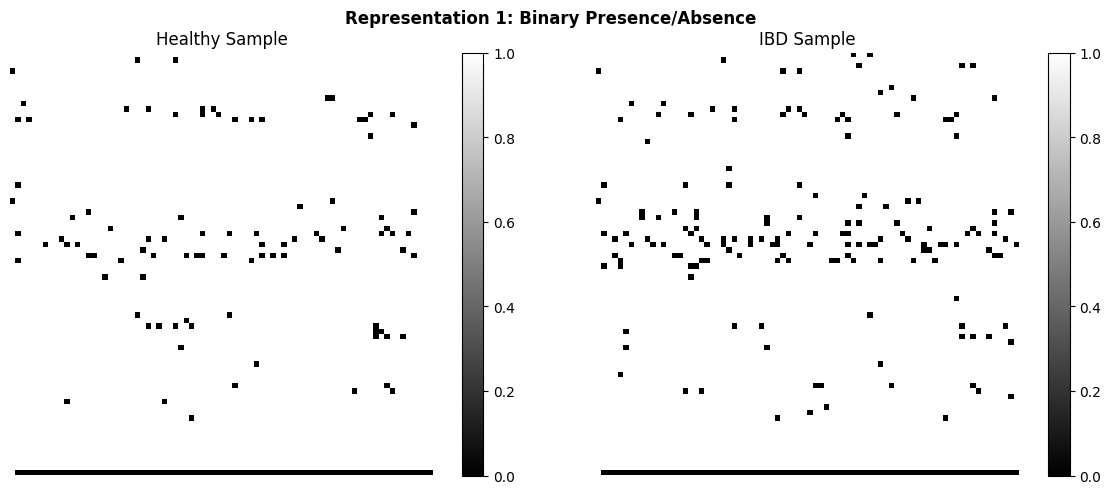


✓ Saved: data/preprocessed/preprocessed_binary.npz



In [74]:
# Binary: pixel = 1.0 (white) if abundance == 0, else 0.0 (black)
X_train_binary = 1.0 - (X_train_raw > 0).astype(np.float32)
X_test_binary = 1.0 - (X_test_raw > 0).astype(np.float32)

# Reshape to 2D images
X_train_binary_2d = np.zeros((n_samples_train, side_length, side_length, 1), dtype=np.float32)
X_test_binary_2d = np.zeros((n_samples_test, side_length, side_length, 1), dtype=np.float32)

for i in range(n_samples_train):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_train_binary[i]
    X_train_binary_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

for i in range(n_samples_test):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_test_binary[i]
    X_test_binary_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

print(f"Representation 1: Binary (1 = abundance > 0, 0 = abundance = 0)")

# Visualize one sample of each class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Representation 1: Binary Presence/Absence', fontsize=12, fontweight='bold')

healthy_idx_train = np.where(y_train == 0)[0][0]
ibd_idx_train = np.where(y_train == 1)[0][0]

ax = axes[0]
im = ax.imshow(X_train_binary_2d[healthy_idx_train, :, :, 0], cmap='gray', interpolation='nearest')
ax.set_title('Healthy Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(X_train_binary_2d[ibd_idx_train, :, :, 0], cmap='gray', interpolation='nearest')
ax.set_title('IBD Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()
print()

# Save
cnn_data_path = 'data/preprocessed/preprocessed_binary.npz'
np.savez_compressed(
    cnn_data_path,
    X_train=X_train_binary_2d,
    X_test=X_test_binary_2d,
    y_train=y_train,
    y_test=y_test
)
print(f"✓ Saved: {cnn_data_path}")
print()

# Representation 2 – Normalized relative abundance

Representation 2: Normalized Relative Abundance (shape: (6549, 78, 78, 1))



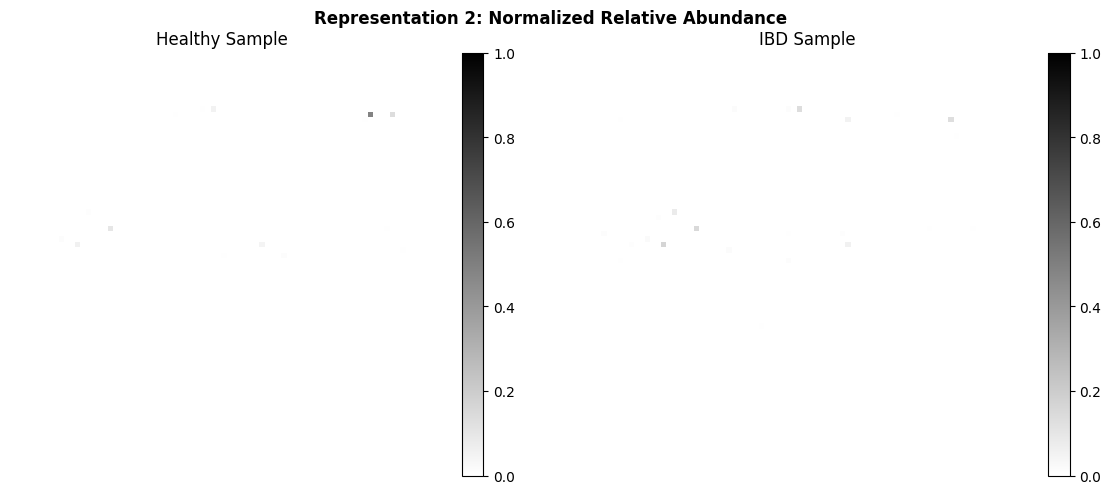


✓ Saved: preprocessed_normalized.npz



In [75]:
# Row-normalize to relative abundance, then min-max normalize per feature (fit on train)
X_train_rel = X_train_raw / X_train_raw.sum(axis=1, keepdims=True)
X_test_rel = X_test_raw / X_test_raw.sum(axis=1, keepdims=True)

# global min-max, fit on train
rel_min = X_train_rel.min()
rel_max = X_train_rel.max()
X_train_rel_norm = np.clip((X_train_rel - rel_min) / (rel_max - rel_min), 0, 1).astype(np.float32)
X_test_rel_norm  = np.clip((X_test_rel  - rel_min) / (rel_max - rel_min), 0, 1).astype(np.float32)

# Reshape to 2D images
X_train_rel_2d = np.zeros((n_samples_train, side_length, side_length, 1), dtype=np.float32)
X_test_rel_2d = np.zeros((n_samples_test, side_length, side_length, 1), dtype=np.float32)

for i in range(n_samples_train):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_train_rel_norm[i]
    X_train_rel_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

for i in range(n_samples_test):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_test_rel_norm[i]
    X_test_rel_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

print(f"Representation 2: Normalized Relative Abundance (shape: {X_train_rel_2d.shape})")
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Representation 2: Normalized Relative Abundance', fontsize=12, fontweight='bold')

ax = axes[0]
im = ax.imshow(X_train_rel_2d[healthy_idx_train, :, :, 0], cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('Healthy Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(X_train_rel_2d[ibd_idx_train, :, :, 0], cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('IBD Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()
print()

# Save
np.savez_compressed(
    'data/preprocessed/preprocessed_normalized.npz',
    X_train=X_train_rel_2d,
    X_test=X_test_rel_2d,
    y_train=y_train,
    y_test=y_test
)
print("✓ Saved: preprocessed_normalized.npz")
print()

# Representation 3 – Log-transformed abundance

Representation 3: Log-Transformed Abundance (shape: (6549, 78, 78, 1))



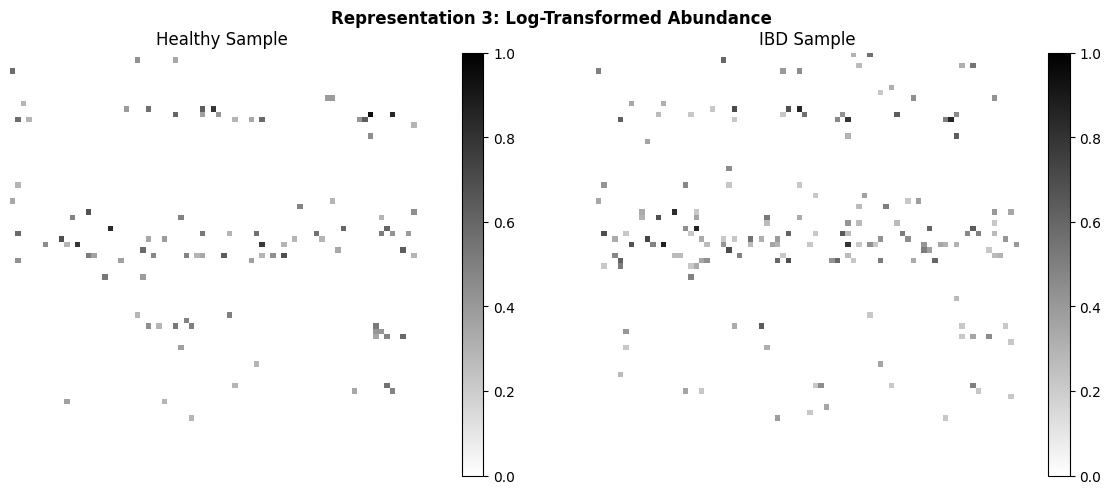


✓ Saved: preprocessed_log.npz



In [76]:
# Relative abundance, then log1p, then min-max normalize per feature (fit on train)
X_train_rel = X_train_raw / X_train_raw.sum(axis=1, keepdims=True)
X_test_rel = X_test_raw / X_test_raw.sum(axis=1, keepdims=True)

pseudocount = 1e-6  # acts as the floor for zeros; tie it to your detection limit if you have one
X_train_log = np.log10(X_train_rel + pseudocount)
X_test_log  = np.log10(X_test_rel  + pseudocount)
    
# global min-max on the log values, fit on train
log_min = X_train_log.min()
log_max = X_train_log.max()
X_train_log_norm = np.clip((X_train_log - log_min) / (log_max - log_min), 0, 1).astype(np.float32)
X_test_log_norm  = np.clip((X_test_log  - log_min) / (log_max - log_min), 0, 1).astype(np.float32)

# Reshape to 2D images
X_train_log_2d = np.zeros((n_samples_train, side_length, side_length, 1), dtype=np.float32)
X_test_log_2d = np.zeros((n_samples_test, side_length, side_length, 1), dtype=np.float32)

for i in range(n_samples_train):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_train_log_norm[i]
    X_train_log_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

for i in range(n_samples_test):
    padded = np.zeros(padded_length)
    padded[:n_features] = X_test_log_norm[i]
    X_test_log_2d[i, :, :, 0] = padded.reshape(side_length, side_length)

print(f"Representation 3: Log-Transformed Abundance (shape: {X_train_log_2d.shape})")
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Representation 3: Log-Transformed Abundance', fontsize=12, fontweight='bold')

ax = axes[0]
im = ax.imshow(X_train_log_2d[healthy_idx_train, :, :, 0], cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('Healthy Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(X_train_log_2d[ibd_idx_train, :, :, 0], cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('IBD Sample')
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()
print()

# Save
np.savez_compressed(
    'data/preprocessed/preprocessed_log.npz',
    X_train=X_train_log_2d,
    X_test=X_test_log_2d,
    y_train=y_train,
    y_test=y_test
)
print("✓ Saved: preprocessed_log.npz")
print()